In [1]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np 
import time 
import os
import sys
import pandas as pd 

from scipy.stats import norm
import time as ttt
import iisignature as iisig
from tqdm import *
from fbm import FBM
import dataframe_image as dfi

import warnings
import math

In [ ]:
#pip install dataframe_image

In [2]:
warnings.filterwarnings("ignore")

In [3]:
r=0.01
sigma=1.0
T=1.0
N=100
dt=T/N

M=1000

In [4]:
def read_data(M, select_type='true'):
    df=pd.read_csv('PPDE_simData/GBM_quarticPPDE1.csv').iloc[:,1:]
    df=df[df['type']==select_type].iloc[:M,:-1]
    for i in range(2,11):
        df_temp=pd.read_csv('PPDE_simData/GBM_quarticPPDE'+str(i)+'.csv').iloc[:,1:]
        df_temp=df_temp[df_temp['type']==select_type].iloc[:M,:-1]
        df=pd.concat([df, df_temp])

    res=df.values
    return res

In [5]:
def cov_df(samples): 
    samples_loc=samples[:,1:]
    corr_mat=pd.DataFrame(samples_loc)
    return corr_mat

def H_idxFunction(samples,N):
    res=np.mean(0.5*(1-np.log(np.sum((samples[:,:-1]-samples[:,1:])**2,axis=1))/np.log(N)))
    return res

def H_idxFunctionSTD(samples,N):
    res=np.std(0.5*(1-np.log(np.sum((samples[:,:-1]-samples[:,1:])**2,axis=1))/np.log(N)))
    return res

## True BS data

In [6]:
def GetBM(select_type):
    Xvec=read_data(M ,select_type=select_type)
    #Xvec[Xvec<1e-3]
    Xvec[Xvec<1e-3]=0.01

    Xvec=torch.tensor(Xvec,dtype=torch.float32)
    dWvec=(np.log(Xvec[:,1:]/Xvec[:,:-1])-(r-0.5*sigma**2)*dt)/sigma
    ## Create BM path
    BM1=torch.hstack([torch.zeros(dWvec.shape[0]).unsqueeze(1),dWvec]) 
    BM1=torch.cumsum(BM1, axis=1)
    
    BM1=BM1.cpu().detach().numpy()
    return Xvec.cpu().detach().numpy(), dWvec.cpu().detach().numpy(),BM1 

In [12]:
Xvec_true,dw_true, BM_true=GetBM('true')
Xvec_ve,dw_ve, BM_ve=GetBM('og')
Xvec_vp,dw_vp, BM_vp=GetBM('vp')
Xvec_sig,dw_sig, BM_sig=GetBM('sig')

In [15]:
cov_true=cov_df(BM_true)
cov_ve=cov_df(BM_ve)
cov_vp=cov_df(BM_vp)
cov_sig=cov_df(BM_sig)

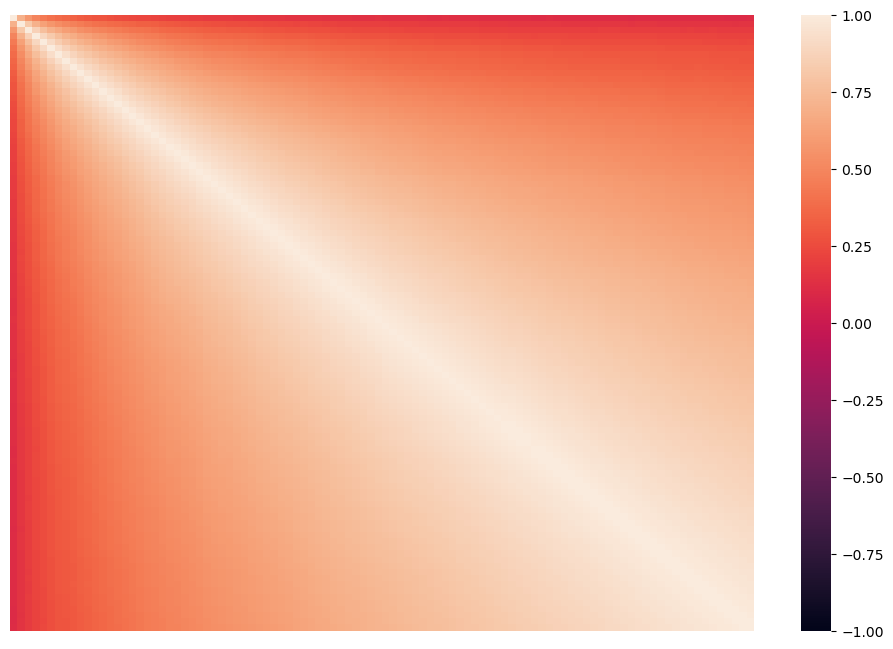

In [31]:
plt.figure(figsize=(12,8))
heatmap = sns.heatmap(cov_vp.corr(), vmin=-1, vmax=1, annot=False,xticklabels=False,yticklabels=False)
#plt.savefig('BS/bs_vp_correlation.png')

In [33]:
Hurst_index={'Data_true':H_idxFunction(BM_true,100),
'VE':H_idxFunction(BM_ve,100),
 'VP': H_idxFunction(BM_vp,100),
 'Sig': H_idxFunction(BM_sig,100)}

Hurst_index_std={'Data_true':H_idxFunctionSTD(BM_true,100),
'VE':H_idxFunctionSTD(BM_ve,100),
 'VP': H_idxFunctionSTD(BM_vp,100),
 'Sig': H_idxFunctionSTD(BM_sig,100)}


Hurst_index,Hurst_index_std

({'Data_true': 0.5009766,
  'VE': 0.4905185,
  'VP': 0.49459898,
  'Sig': 0.49050087},
 {'Data_true': 0.015569584,
  'VE': 0.025479447,
  'VP': 0.020251313,
  'Sig': 0.02626338})

In [34]:
from scipy.stats import skew, kurtosis

In [35]:
dw_true.mean(),dw_true.var(), skew(dw_true.flatten()),kurtosis(dw_true.flatten())

(2.0006573e-05, 0.010012152, 0.0011380313595735672, -0.004439619153121299)

In [36]:
def summarize_percentiles(data, percentiles=None, decimals=2):
    """
    Calculate and summarize percentiles of a dataset.
    
    Parameters:
    - data: List or array-like, the input data
    - percentiles: List of percentiles to calculate (default: [25, 50, 75, 90, 95, 99])
    - decimals: Number of decimal places to round results (default: 2)
    
    Returns:
    - Dictionary with percentile values and basic statistics
    """
    if percentiles is None:
        percentiles = [1, 5, 15, 25, 50, 75, 90, 95, 99]
    
    
    try:
        data_array = np.array(data)
        valid_data = data_array[~np.isnan(data_array)]
        
        if len(valid_data) == 0:
            return {"error": "No valid numeric data found"}
        
        results = {
            "count": len(valid_data),
            "min": round(float(np.min(valid_data)), decimals),
            "max": round(float(np.max(valid_data)), decimals),
            "mean": round(float(np.mean(valid_data)), decimals),
            "std": round(float(np.std(valid_data)), decimals)
        }
        
        # Calculate requested percentiles
        percentile_values = np.percentile(valid_data, percentiles)
        for p, val in zip(percentiles, percentile_values):
            results[f'p{p}'] = round(float(val), decimals)
        
        return results
    
    except Exception as e:
        return {"error": f"An error occurred: {str(e)}"}

In [37]:
df_trueStats=summarize_percentiles(dw_true.flatten(), percentiles=None, decimals=2)
df_veStats=summarize_percentiles(dw_ve.flatten(), percentiles=None, decimals=2)
df_vpStats=summarize_percentiles(dw_vp.flatten(), percentiles=None, decimals=2)
df_sigStats=summarize_percentiles(dw_sig.flatten(), percentiles=None, decimals=2)

In [38]:
df=pd.DataFrame(columns=df_trueStats.keys()).transpose()

In [39]:
df['Data_true']=df_trueStats.values()
df['ve']=df_veStats.values()
df['vp']=df_vpStats.values()
#df['sig']=df_sigStats.values()

In [41]:
df.iloc[1:,]

,Data_true,ve,vp
min,-0.47,-2.51,-1.82
max,0.47,1.98,1.62
mean,0.00,-0.00,-0.00
std,0.10,0.11,0.10
p1,-0.23,-0.25,-0.24
p5,-0.16,-0.17,-0.17
p15,-0.10,-0.11,-0.11
p25,-0.07,-0.07,-0.07
p50,0.00,0.00,0.00
p75,0.07,0.07,0.07


In [43]:
def save_df_as_image(df, file_path):
    plt.figure(figsize=(10, 6))
    sns.heatmap(df, annot=True, cmap='YlGnBu', fmt='g', cbar=False)
    plt.savefig(file_path, bbox_inches='tight')
    plt.close()

In [44]:
df

,Data_true,ve,vp
count,1000000.00,1000000.00,1000000.00
min,-0.47,-2.51,-1.82
max,0.47,1.98,1.62
mean,0.00,-0.00,-0.00
std,0.10,0.11,0.10
p1,-0.23,-0.25,-0.24
p5,-0.16,-0.17,-0.17
p15,-0.10,-0.11,-0.11
p25,-0.07,-0.07,-0.07
p50,0.00,0.00,0.00


In [45]:
#save_df_as_image(df.iloc[1:,:], 'BS/table.png')

# Checking the following: 
$$\max_{0 \leq t \leq T} S_t -S_T $$

In [22]:
vec_true=Xvec_true.max(axis=1)-Xvec_true[:,-1]
vec_ve=Xvec_ve.max(axis=1)-Xvec_ve[:,-1]
vec_vp=Xvec_vp.max(axis=1)-Xvec_vp[:,-1]
vec_sig=Xvec_sig.max(axis=1)-Xvec_sig[:,-1]

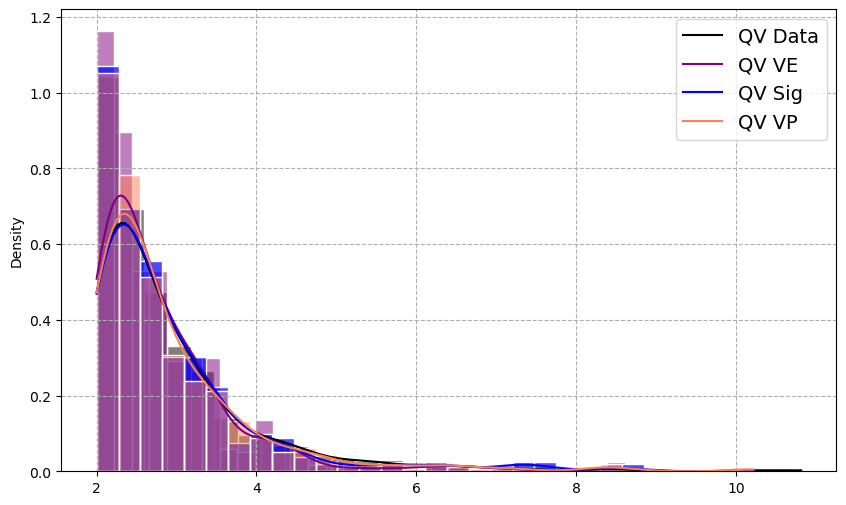

In [23]:
ll=2
plt.figure(figsize=(10, 6))
sns.histplot(vec_true[vec_true>ll], bins=30, kde=True, 
             color='black', edgecolor='white',
             stat='density')
sns.histplot(vec_vp[vec_vp>ll], bins=30, kde=True, 
             color='purple', edgecolor='white',
             stat='density')
sns.histplot(vec_ve[vec_ve>ll], bins=30, kde=True, 
             color='blue', edgecolor='white',
             stat='density', alpha=0.7)
sns.histplot(vec_sig[vec_sig>ll], bins=30, kde=True, 
             color='coral', edgecolor='white',
             stat='density')
plt.legend(['QV Data', 'QV VE','QV Sig','QV VP'],fontsize=14)
plt.grid(linestyle='--')

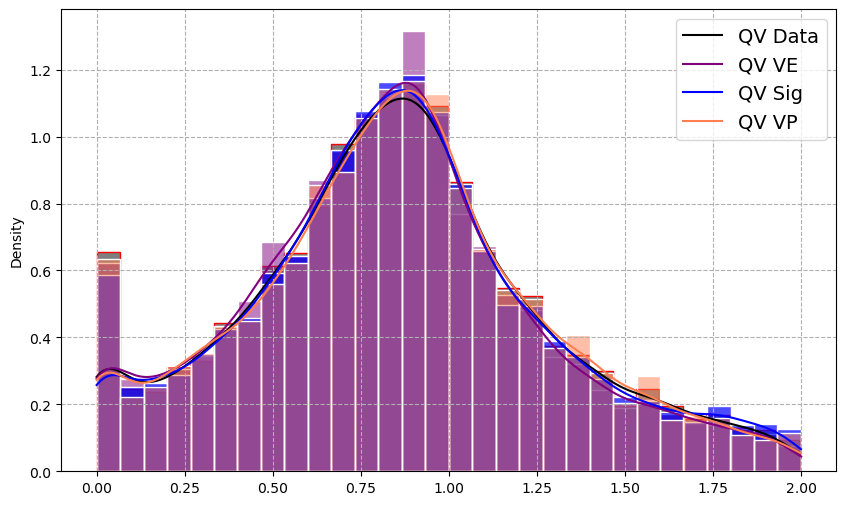

In [24]:
ll=2
plt.figure(figsize=(10, 6))
sns.histplot(vec_true[vec_true<ll], bins=30, kde=True, 
             color='black', edgecolor='red',
             stat='density')
sns.histplot(vec_vp[vec_vp<ll], bins=30, kde=True, 
             color='purple', edgecolor='white',
             stat='density')
sns.histplot(vec_ve[vec_ve<ll], bins=30, kde=True, 
             color='blue', edgecolor='white',
             stat='density', alpha=0.7)
sns.histplot(vec_sig[vec_sig<ll], bins=30, kde=True, 
             color='coral', edgecolor='white',
             stat='density')
plt.legend(['QV Data', 'QV VE','QV Sig','QV VP'],fontsize=14)
plt.grid(linestyle='--')

# Statistical test

## Komogorov Test

In [25]:
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp

In [26]:
# Null hypothesis is that the two distributions are the same. < 0.05 reject
stat, p_value = ks_2samp(vec_true, vec_ve)
if p_value > 0.05:
    print("The p-value is "+ str(p_value)+" Fail to reject null hypothesis - distributions may be the same")
else:
    print("The p-value is "+str(p_value)+ " Reject null hypothesis - distributions are different")

The p-value is 0.9906834584178017 Fail to reject null hypothesis - distributions may be the same


In [27]:
ll=3.0
stat, p_value = ks_2samp(vec_true[vec_true<ll], vec_vp[vec_vp<ll])
if p_value > 0.05:
    print("The p-value is "+ str(p_value)+" Fail to reject null hypothesis - distributions may be the same")
else:
    print("The p-value is "+str(p_value)+ " Reject null hypothesis - distributions are different")

The p-value is 0.0015279116719708807 Reject null hypothesis - distributions are different


In [28]:
stat, p_value = ks_2samp(vec_true, vec_sig)
if p_value > 0.05:
    print("The p-value is "+ str(p_value)+" Fail to reject null hypothesis - distributions may be the same")
else:
    print("The p-value is "+str(p_value)+ " Reject null hypothesis - distributions are different")

The p-value is 0.8435889342947497 Fail to reject null hypothesis - distributions may be the same


## Anderson Darling Test

In [34]:
# Null hypothesis is that the two distributions are the same. < 0.05 reject
result = anderson_ksamp([vec_true, vec_sig])
if result.significance_level < 0.05:
    print("The p-value is "+str(result.significance_level)+"Distributions are significantly different")
    
if result.significance_level > 0.05:
    print("The p-value is "+str(result.significance_level)+" Distributions may be the same")

The p-value is 0.25 Distributions may be the same


In [35]:
result = anderson_ksamp([vec_true, vec_ve])
if result.significance_level < 0.05:
    print("The p-value is "+str(result.significance_level)+"Distributions are significantly different")
    
if result.significance_level > 0.05:
    print("The p-value is "+str(result.significance_level)+" Distributions may be the same")

The p-value is 0.25 Distributions may be the same


In [36]:
result = anderson_ksamp([vec_true, vec_vp])
if result.significance_level < 0.05:
    print("The p-value is "+str(result.significance_level)+" Distributions are significantly different")
    
if result.significance_level > 0.05:
    print("The p-value is "+str(result.significance_level)+ " Distributions may be the same")

The p-value is 0.001 Distributions are significantly different


In [37]:
result = anderson_ksamp([vec_true, vec_sig])
if result.significance_level < 0.05:
    print("The p-value is "+str(result.significance_level)+" Distributions are significantly different")
    
if result.significance_level > 0.05:
    print("The p-value is "+str(result.significance_level)+ " Distributions may be the same")

The p-value is 0.25 Distributions may be the same
